In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote
from matplotlib import pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# параметры подключения
username = "student"
password = "123456sql@"
host = "rc1b-cpsjckr2wfkuk61s.mdb.yandexcloud.net"
port = "6432"
database = "Northwind"

# Кодируем пароль
encoded_password = quote(password)
print(encoded_password)

# Формируем строку подключения
connection_string = f'postgresql+psycopg2://{username}:{encoded_password}@{host}:{port}/{database}'
engine = create_engine(connection_string)

123456sql%40


In [3]:
#sql запрос
query = """
select date(event_time)as dt,

count(distinct user_session) as sessions,
count(distinct (case when event_type  = 'purchase' then user_session end)) as sessions_with_purchase,

count(distinct user_id) as dau,
count(distinct (case when event_type  = 'view' then user_id end)) as users_with_view,
count(distinct (case when event_type  = 'cart' then user_id end)) as users_with_cart,
count(distinct (case when event_type  = 'purchase' then user_id end)) as users_with_purchase,

sum(case when event_type  = 'purchase' then price end) as gmv_created

from sandbox.events_201911
group by  date(event_time)
"""
df = pd.read_sql_query(query, engine)
df.head()

,dt,sessions,sessions_with_purchase,dau,users_with_view,users_with_cart,users_with_purchase,gmv_created
0,2019-11-01,25277,928,14870,14117,3891,913,37134.18
1,2019-11-02,24614,826,14609,13915,3751,818,33607.52
2,2019-11-03,26337,902,15525,14845,4045,888,36582.87
3,2019-11-04,26233,956,16201,15376,4350,945,39564.03
4,2019-11-05,32053,1041,18524,17632,4821,1021,41859.68


In [4]:
#дата имеет тип данных object
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dt                      30 non-null     object 
 1   sessions                30 non-null     int64  
 2   sessions_with_purchase  30 non-null     int64  
 3   dau                     30 non-null     int64  
 4   users_with_view         30 non-null     int64  
 5   users_with_cart         30 non-null     int64  
 6   users_with_purchase     30 non-null     int64  
 7   gmv_created             30 non-null     float64
dtypes: float64(1), int64(6), object(1)
memory usage: 2.0+ KB


In [5]:
#перевожу дату в формат datetime
df['dt'] = df.dt.astype('datetime64[ns]')

#### Daily Active Users (DAU)

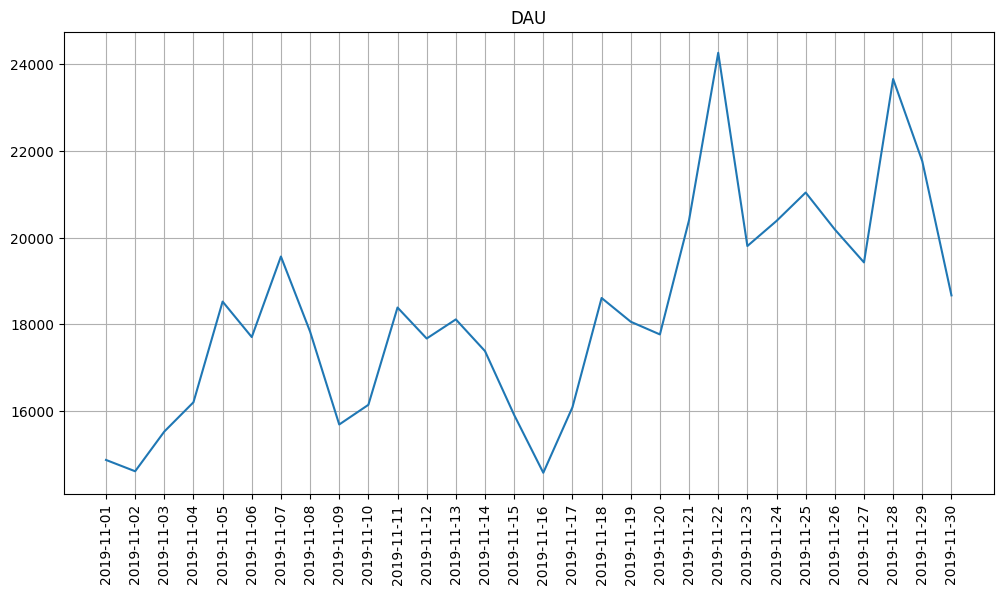

In [6]:
plt.figure(figsize = (12,6))
plt.plot(df.dt, df.dau)
plt.grid()
plt.title('DAU')
plt.xticks(df.dt, rotation = 90)
plt.show()

#### Конверсия (Conversion Rate) из DAU в DAC

**DAU** - Daily Active Users </br>
**DAC** - Daily Active Customers

In [7]:
#DAU гораздо больше DAC (users_with_purchase - это DAC)
df.head()

,dt,sessions,sessions_with_purchase,dau,users_with_view,users_with_cart,users_with_purchase,gmv_created
0,2019-11-01,25277,928,14870,14117,3891,913,37134.18
1,2019-11-02,24614,826,14609,13915,3751,818,33607.52
2,2019-11-03,26337,902,15525,14845,4045,888,36582.87
3,2019-11-04,26233,956,16201,15376,4350,945,39564.03
4,2019-11-05,32053,1041,18524,17632,4821,1021,41859.68


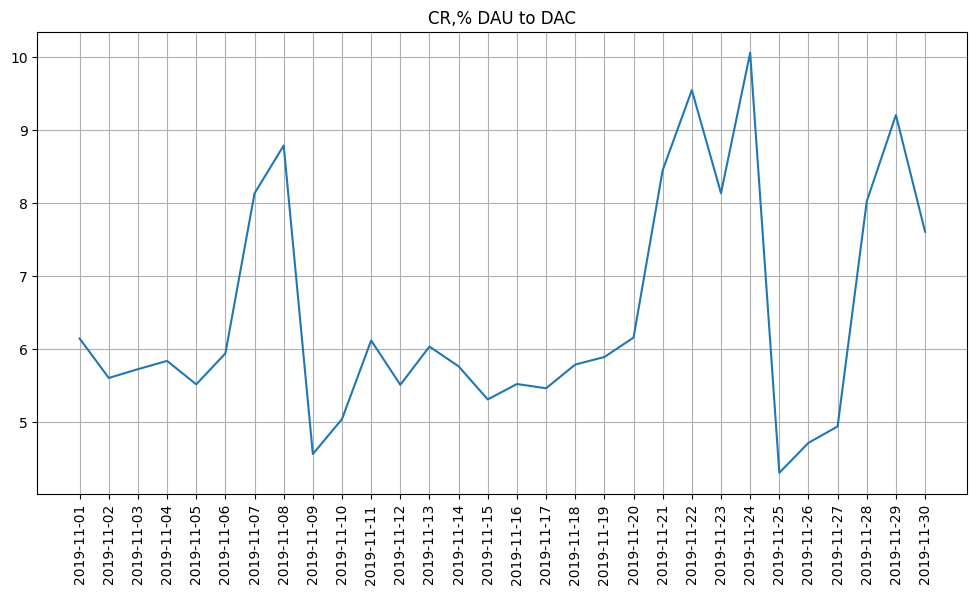

In [8]:
plt.figure(figsize = (12,6))
plt.plot(df.dt, df.users_with_purchase/df.dau * 100)
plt.grid()
plt.title('CR,% DAU to DAC')
plt.xticks(df.dt, rotation = 90)
plt.show()

#### Конверсия из Sessions в Sessions with purchase

In [9]:
df.head()

,dt,sessions,sessions_with_purchase,dau,users_with_view,users_with_cart,users_with_purchase,gmv_created
0,2019-11-01,25277,928,14870,14117,3891,913,37134.18
1,2019-11-02,24614,826,14609,13915,3751,818,33607.52
2,2019-11-03,26337,902,15525,14845,4045,888,36582.87
3,2019-11-04,26233,956,16201,15376,4350,945,39564.03
4,2019-11-05,32053,1041,18524,17632,4821,1021,41859.68


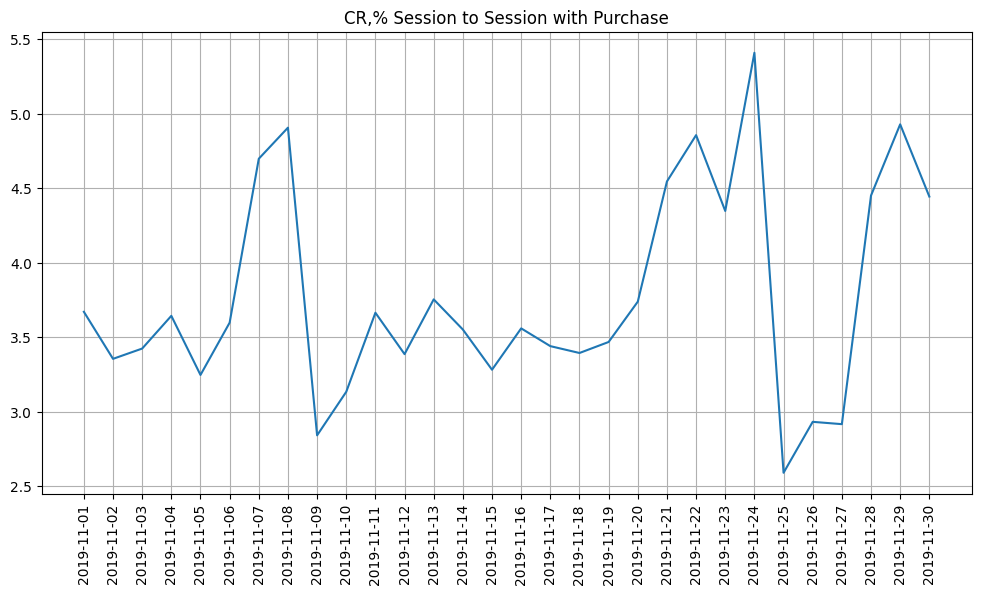

In [10]:
plt.figure(figsize = (12,6))
plt.plot(df.dt, df.sessions_with_purchase/df.sessions * 100)
plt.grid()
plt.title('CR,% Session to Session with Purchase')
plt.xticks(df.dt, rotation = 90)
plt.show()

#### Конверсионная воронка view -> cart -> purchase

In [11]:
df.head()

,dt,sessions,sessions_with_purchase,dau,users_with_view,users_with_cart,users_with_purchase,gmv_created
0,2019-11-01,25277,928,14870,14117,3891,913,37134.18
1,2019-11-02,24614,826,14609,13915,3751,818,33607.52
2,2019-11-03,26337,902,15525,14845,4045,888,36582.87
3,2019-11-04,26233,956,16201,15376,4350,945,39564.03
4,2019-11-05,32053,1041,18524,17632,4821,1021,41859.68


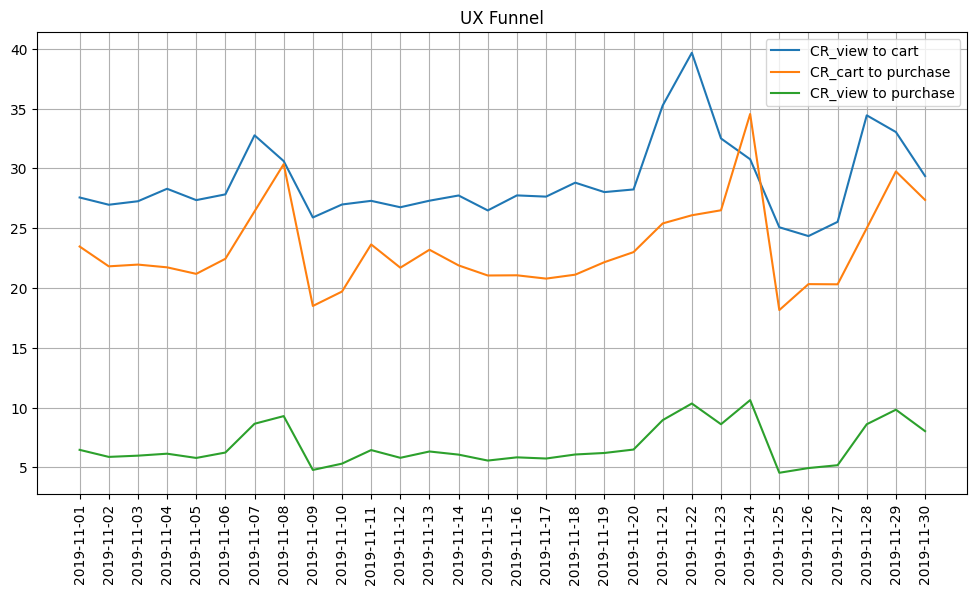

In [12]:
plt.figure(figsize = (12,6))
plt.plot(df.dt, df.users_with_cart/df.users_with_view * 100, label = 'CR_view to cart')
plt.plot(df.dt, df.users_with_purchase/df.users_with_cart * 100, label = 'CR_cart to purchase')
plt.plot(df.dt, df.users_with_purchase/df.users_with_view * 100, label = 'CR_view to purchase')
plt.legend()
plt.grid()
plt.title('UX Funnel')
plt.xticks(df.dt, rotation = 90)
plt.show()

#### ARPPU и ARPU

**ARPU** - Average Revenue Per User </br>
**ARPPU** - Average Revenue Per Paying User

In [13]:
df.head()

,dt,sessions,sessions_with_purchase,dau,users_with_view,users_with_cart,users_with_purchase,gmv_created
0,2019-11-01,25277,928,14870,14117,3891,913,37134.18
1,2019-11-02,24614,826,14609,13915,3751,818,33607.52
2,2019-11-03,26337,902,15525,14845,4045,888,36582.87
3,2019-11-04,26233,956,16201,15376,4350,945,39564.03
4,2019-11-05,32053,1041,18524,17632,4821,1021,41859.68


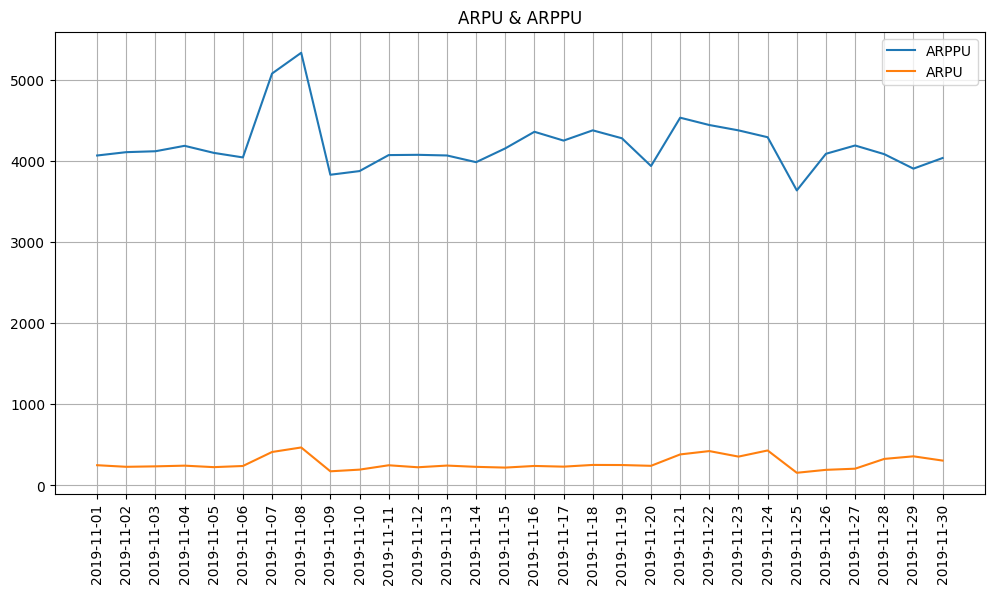

In [15]:
plt.figure(figsize = (12,6))
plt.plot(df.dt, df.gmv_created/df.users_with_purchase * 100, label = 'ARPPU')
plt.plot(df.dt, df.gmv_created/df.dau * 100, label = 'ARPU')
plt.legend()
plt.grid()
plt.title('ARPU & ARPPU')
plt.xticks(df.dt, rotation = 90)
plt.show()